# Histogramas de variables cuantitativas
Visualización directa de las variables solicitadas para evaluar de forma rápida si parecen aproximarse a una distribución normal.

In [5]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("movies_2026.csv")
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")

## Columnas cuantitativas consideradas
- Continuas: runtime · popularity · budget · revenue · voteAvg · actorsPopularity · releaseDate
- Discretas: genresAmount · productionCoAmount · productionCountriesAmount · voteCount · actorsAmount · castWomenAmount · castMenAmount · releaseYear

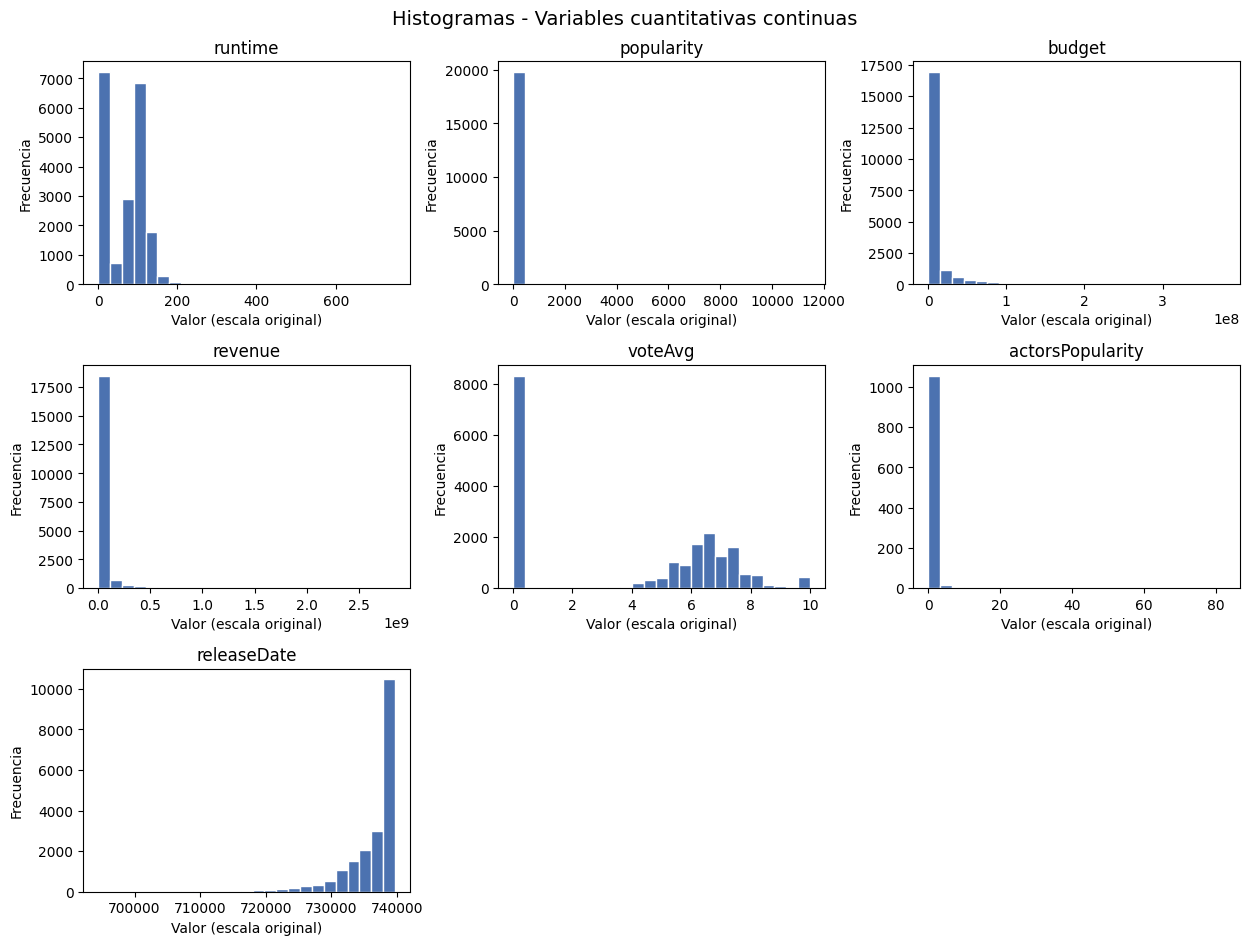

In [6]:
continuous_cols = [
    "runtime",
    "popularity",
    "budget",
    "revenue",
    "voteAvg",
    "actorsPopularity",
    "releaseDate",
]

discrete_cols = [
    "genresAmount",
    "productionCoAmount",
    "productionCountriesAmount",
    "voteCount",
    "actorsAmount",
    "castWomenAmount",
    "castMenAmount",
    "releaseYear",
]

available_continuous = [col for col in continuous_cols if col in df.columns]
available_discrete = [col for col in discrete_cols if col in df.columns]
missing_cols = [
    col
    for col in continuous_cols + discrete_cols
    if col not in df.columns
]
if missing_cols:
    print("No se encontraron las columnas:", missing_cols)


def to_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_datetime64_any_dtype(series):
        return series.dropna().map(pd.Timestamp.toordinal)
    return pd.to_numeric(series, errors="coerce").dropna()


def plot_histograms(columns, title):
    cols = 3
    rows = math.ceil(len(columns) / cols) or 1
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.2))
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        values = to_numeric(df[col])
        ax.hist(values, bins=25, color="#4c72b0", edgecolor="white")
        ax.set_title(col)
        ax.set_ylabel("Frecuencia")
        ax.set_xlabel("Valor (escala original)")

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_histograms(available_continuous, "Histogramas - Variables cuantitativas continuas")

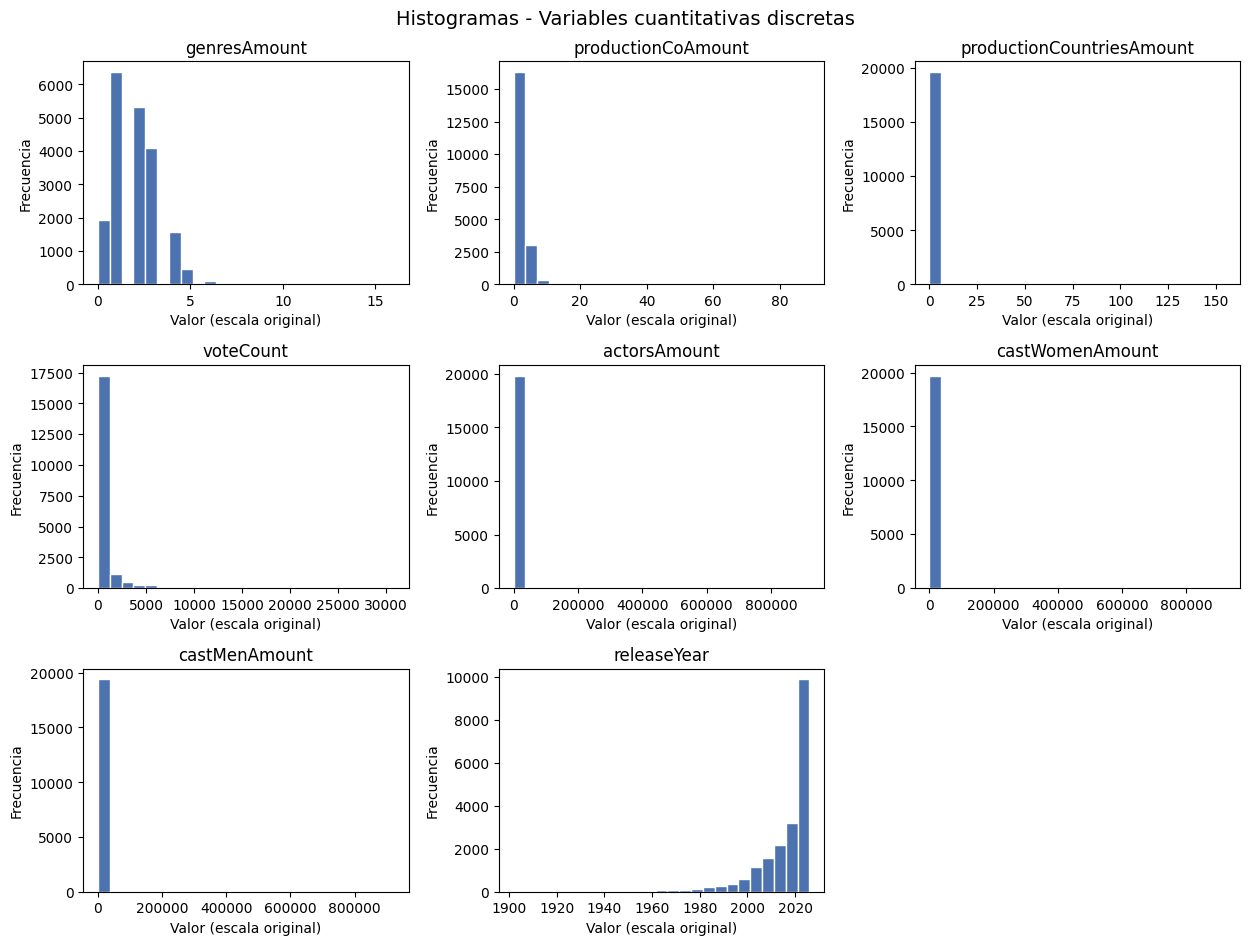

In [7]:
plot_histograms(available_discrete, "Histogramas - Variables cuantitativas discretas")